In [1]:
import pandas as pd

# Read directly from BigQuery
df_users = pd.read_gbq('SELECT * FROM `callcenter-439216.neobank.users`', project_id='callcenter-439216')
df_transaction = pd.read_gbq('SELECT * FROM `callcenter-439216.neobank.transactions`', project_id='callcenter-439216')


C:\Users\Asus\AppData\Local\Temp\ipykernel_31008\787717553.py:4: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_users = pd.read_gbq('SELECT * FROM `callcenter-439216.neobank.users`', project_id='callcenter-439216')
C:\Users\Asus\AppData\Local\Temp\ipykernel_31008\787717553.py:5: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_transaction = pd.read_gbq('SELECT * FROM `callcenter-439216.neobank.transactions`', project_id='callcenter-439216')


In [2]:
df_notifications = pd.read_gbq('SELECT * FROM `callcenter-439216.neobank.notifcations`', project_id='callcenter-439216')

C:\Users\Asus\AppData\Local\Temp\ipykernel_31008\154290738.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_notifications = pd.read_gbq('SELECT * FROM `callcenter-439216.neobank.notifcations`', project_id='callcenter-439216')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.metrics import silhouette_score
from scipy import stats

# Custom function to find most frequent value
def most_frequent(series):
    """Find the most frequent value in a pandas Series"""
    if series.empty or series.isnull().all():
        return None
    clean_series = series.dropna()
    if clean_series.empty:
        return None
    return clean_series.value_counts().index[0]

def remove_outliers_iqr(df, columns, multiplier=1.5):
    """Remove outliers using IQR method"""
    df_clean = df.copy()
    
    # Remove outliers using IQR method
    
    for column in columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        initial_count = len(df_clean)
        df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]
        removed_count = initial_count - len(df_clean)
        
        if removed_count > 0:
            print(f"Removed {removed_count} outliers from {column} (bounds: {lower_bound:.2f} to {upper_bound:.2f})")
    
    return df_clean

In [ ]:
np.random.seed(42)
n_users = 1000

# First create user-level data
user_info = pd.DataFrame({
    'user_id': range(n_users),
    'birth_year': np.random.randint(1970, 2000, n_users),
    'country': np.random.choice(['GB', 'US', 'DE', 'FR'], n_users, p=[0.4, 0.3, 0.2, 0.1]),
    'plan': np.random.choice(['STANDARD', 'PREMIUM', 'BASIC'], n_users, p=[0.6, 0.25, 0.15]),
    'attributes_notifications_marketing_push': np.random.choice([0, 1], n_users),
    'attributes_notifications_marketing_email': np.random.choice([0, 1], n_users)
})

# Create transaction data by replicating user info for multiple transactions
transaction_data = []
for _, user in user_info.iterrows():
    n_transactions = np.random.poisson(10) + 1  # At least 1 transaction
    for _ in range(n_transactions):
        transaction_data.append({
            'user_id': user['user_id'],
            'birth_year': user['birth_year'],
            'country': user['country'],
            'plan': user['plan'],
            'attributes_notifications_marketing_push': user['attributes_notifications_marketing_push'],
            'attributes_notifications_marketing_email': user['attributes_notifications_marketing_email'],
            'amount_usd': np.random.lognormal(8, 2),
            'transactions_state': np.random.choice(['COMPLETED', 'FAILED'], p=[0.8, 0.2]),
            'status': np.random.choice(['SENT', 'NOT_SENT'], p=[0.7, 0.3])
        })

all_data = pd.DataFrame(transaction_data)

print(f"Total rows: {len(all_data)}")

Loading data...
Creating sample data for demonstration...
Total rows: 10983


In [ ]:


print("Creating user features...")

# Calculate age
current_year = 2024
all_data['age'] = current_year - all_data['birth_year']

# Create user-level summaries
user_data = all_data.groupby('user_id').agg({
    'age': 'first',
    'country': 'first', 
    'plan': 'first',
    'amount_usd': ['count', 'mean', 'sum', 'std'],
    'transactions_state': lambda x: (x == 'COMPLETED').mean(),
    'status': lambda x: (x == 'SENT').mean(),
    'attributes_notifications_marketing_push': 'first',
    'attributes_notifications_marketing_email': 'first'
}).round(2)

# Flatten column names
user_data.columns = [
    'age', 'country', 'plan', 'transaction_count', 'avg_amount', 
    'total_amount', 'amount_std', 'success_rate', 'notification_rate', 
    'marketing_push', 'marketing_email'
]

print(f"Users: {len(user_data)}")

Creating user features...
Users: 1000


In [ ]:
print("Handling missing values...")

# Numeric features - fill with median
numeric_cols = ['age', 'transaction_count', 'avg_amount', 'total_amount', 'amount_std', 'success_rate', 'notification_rate']
for col in numeric_cols:
    median_val = user_data[col].median()
    user_data[col] = user_data[col].fillna(median_val)

# Fill missing std with 0 (single transaction users)
user_data['amount_std'] = user_data['amount_std'].fillna(0)

# Categorical features - fill with most frequent
categorical_cols = ['country', 'plan']
for col in categorical_cols:
    frequent_val = most_frequent(user_data[col])
    user_data[col] = user_data[col].fillna(frequent_val if frequent_val else 'UNKNOWN')

# Binary features - fill with most frequent
binary_cols = ['marketing_push', 'marketing_email']
for col in binary_cols:
    frequent_val = most_frequent(user_data[col])
    user_data[col] = user_data[col].fillna(frequent_val if frequent_val else 0)

print("Missing values handled")

Handling missing values...
Missing values handled


In [ ]:


print("\nDetecting and removing outliers...")

# Show some statistics before outlier removal
print("\nBefore outlier removal:")
for col in ['transaction_count', 'avg_amount', 'total_amount']:
    print(f"{col}: min={user_data[col].min():.2f}, max={user_data[col].max():.2f}, "
          f"mean={user_data[col].mean():.2f}, std={user_data[col].std():.2f}")

# Remove outliers from key numeric features
outlier_cols = ['transaction_count', 'avg_amount', 'total_amount']
user_data_clean = remove_outliers_iqr(user_data, outlier_cols, multiplier=2.0)

print(f"\nUsers after outlier removal: {len(user_data_clean)} (removed {len(user_data) - len(user_data_clean)} users)")

# Show statistics after outlier removal
print("\nAfter outlier removal:")
for col in ['transaction_count', 'avg_amount', 'total_amount']:
    print(f"{col}: min={user_data_clean[col].min():.2f}, max={user_data_clean[col].max():.2f}, "
          f"mean={user_data_clean[col].mean():.2f}, std={user_data_clean[col].std():.2f}")


Detecting and removing outliers...

Before outlier removal:
transaction_count: min=3.00, max=21.00, mean=10.98, std=3.25
avg_amount: min=477.98, max=866417.37, mean=22213.37, std=40387.34
total_amount: min=2389.91, max=6064921.62, mean=245572.03, std=415324.24
Removed 61 outliers from avg_amount (bounds: -25456.88 to 56595.66)
Removed 26 outliers from total_amount (bounds: -258573.30 to 560390.72)

Users after outlier removal: 913 (removed 87 users)

After outlier removal:
transaction_count: min=3.00, max=21.00, mean=10.86, std=3.18
avg_amount: min=477.98, max=56054.57, mean=14785.25, std=10631.54
total_amount: min=2389.91, max=555395.62, mean=160977.84, std=120395.79


we create user-level features such as transaction counts, average and total spending, success rates, and notification activity

In [ ]:
print("\nEngineering additional features")

# Create spending behavior categories
user_data_clean['avg_amount_log'] = np.log1p(user_data_clean['avg_amount'])
user_data_clean['total_amount_log'] = np.log1p(user_data_clean['total_amount'])

# Create transaction frequency categories
user_data_clean['transaction_frequency'] = pd.qcut(
    user_data_clean['transaction_count'], 
    q=4, 
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Create age groups
user_data_clean['age_group'] = pd.cut(
    user_data_clean['age'], 
    bins=[0, 30, 40, 50, 100], 
    labels=['Young', 'Adult', 'Middle-aged', 'Senior']
)


Engineering additional features...


For clustering, numeric features are scaled using RobustScaler, while categorical variables (country, plan) are encoded with one-hot encoding. We then evaluate different cluster sizes with the Elbow method and Silhouette score, selecting the optimal number of clusters based on performance.

In [ ]:
print("Preparing features for clustering")

# Select features for clustering (use log-transformed amounts to reduce skewness)
features_to_use = ['age', 'transaction_count', 'avg_amount_log', 'total_amount_log', 'success_rate', 'country', 'plan']
clustering_data = user_data_clean[features_to_use].copy()

# Separate numeric and categorical
numeric_features = ['age', 'transaction_count', 'avg_amount_log', 'total_amount_log', 'success_rate']
categorical_features = ['country', 'plan']

# Scale numeric features using RobustScaler (less sensitive to outliers)
scaler = RobustScaler()
numeric_scaled = pd.DataFrame(
    scaler.fit_transform(clustering_data[numeric_features]),
    columns=numeric_features,
    index=clustering_data.index
)

Preparing features for clustering...


In [60]:


# One-hot encode categorical features
encoder = OneHotEncoder(drop='first', sparse_output=False)
categorical_encoded = pd.DataFrame(
    encoder.fit_transform(clustering_data[categorical_features]),
    columns=encoder.get_feature_names_out(),
    index=clustering_data.index
)

# Combine features
final_features = pd.concat([numeric_scaled, categorical_encoded], axis=1)
X = final_features.values

print(f"Final features shape: {final_features.shape}")
print("Feature names:", list(final_features.columns))

Final features shape: (913, 10)
Feature names: ['age', 'transaction_count', 'avg_amount_log', 'total_amount_log', 'success_rate', 'country_FR', 'country_GB', 'country_US', 'plan_PREMIUM', 'plan_STANDARD']



Finding optimal number of clusters...


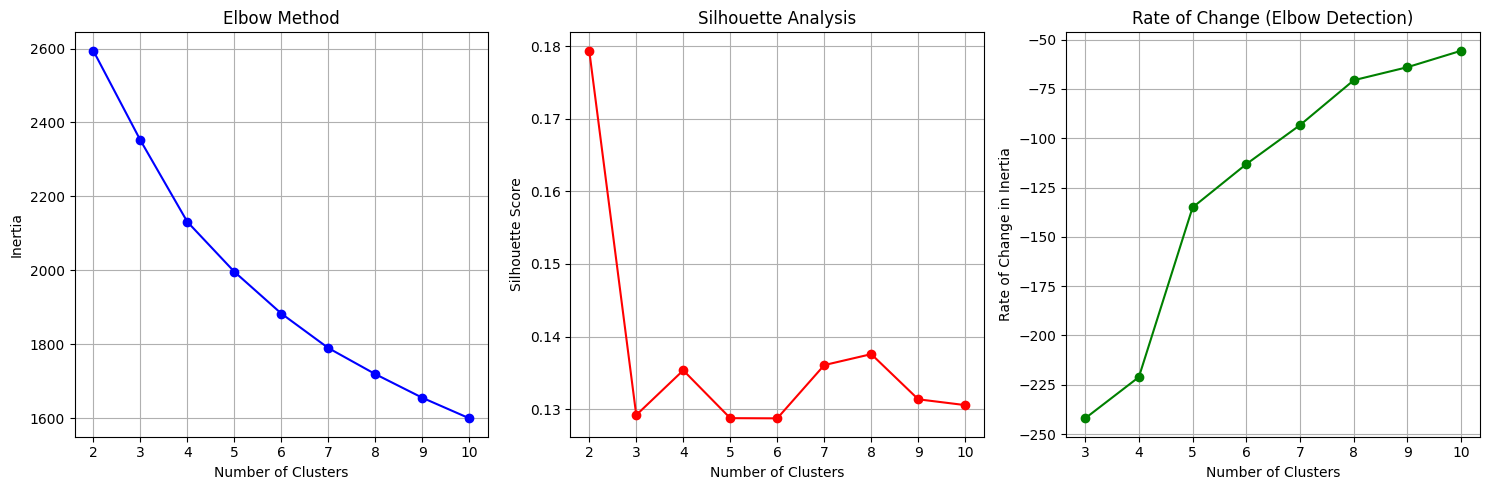

Optimal number of clusters based on silhouette score: 2
Best silhouette score: 0.179


In [ ]:



print("\nFinding optimal number of clusters")

# Test different numbers of clusters
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    
    # Only calculate silhouette score if we have enough samples
    if len(np.unique(labels)) > 1:
        silhouette_scores.append(silhouette_score(X, labels))
    else:
        silhouette_scores.append(0)

# Plot results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True)

# Calculate rate of change for elbow method
plt.subplot(1, 3, 3)
rate_of_change = np.diff(inertias)
plt.plot(k_range[1:], rate_of_change, 'go-')
plt.xlabel('Number of Clusters')
plt.ylabel('Rate of Change in Inertia')
plt.title('Rate of Change (Elbow Detection)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Choose optimal k based on silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")

In [ ]:

print(f"\nPerforming clustering with {optimal_k} clusters...")

# Final clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Add clusters to user data
user_data_clean['cluster'] = clusters

print("Clustering complete")


Performing clustering with 2 clusters...
Clustering complete


K-Means clustering is applied to segment customers into distinct groups. Each cluster is analyzed in terms of size, transaction behavior, spending levels, country distribution, and plan types

In [ ]:
print("\nAnalyzing clusters")

# Cluster sizes
print("\nCluster sizes:")
cluster_counts = pd.Series(clusters).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = count/len(user_data_clean)*100
    print(f"Cluster {cluster_id}: {count} users ({percentage:.1f}%)")

# Cluster characteristics for numeric features
print("\nCluster characteristics (numeric features):")
numeric_summary_cols = ['age', 'transaction_count', 'avg_amount', 'total_amount', 'success_rate', 'notification_rate']
cluster_summary = user_data_clean.groupby('cluster')[numeric_summary_cols].agg(['mean', 'std']).round(2)
print(cluster_summary)

# Most common values for categorical features
print("\nMost common categorical values by cluster:")
for cluster_id in sorted(user_data_clean['cluster'].unique()):
    cluster_subset = user_data_clean[user_data_clean['cluster'] == cluster_id]
    common_country = most_frequent(cluster_subset['country'])
    common_plan = most_frequent(cluster_subset['plan'])
    common_age_group = most_frequent(cluster_subset['age_group'])
    common_transaction_freq = most_frequent(cluster_subset['transaction_frequency'])
    
    print(f"Cluster {cluster_id}: Country={common_country}, Plan={common_plan}, "
          f"Age Group={common_age_group}, Transaction Freq={common_transaction_freq}")


Analyzing clusters...

Cluster sizes:
Cluster 0: 399 users (43.7%)
Cluster 1: 514 users (56.3%)

Cluster characteristics (numeric features):
           age       transaction_count       avg_amount            \
          mean   std              mean   std       mean       std   
cluster                                                             
0        39.27  9.10              9.35  2.69    6875.99   3415.94   
1        38.88  9.08             12.03  3.04   20924.93  10269.60   

        total_amount            success_rate       notification_rate        
                mean        std         mean   std              mean   std  
cluster                                                                     
0           61571.60   27019.78         0.81  0.14              0.71  0.16  
1          238143.38  107475.23         0.80  0.12              0.71  0.13  

Most common categorical values by cluster:
Cluster 0: Country=GB, Plan=STANDARD, Age Group=Adult, Transaction Freq=Low
Cluster

In [ ]:
print("\nDetailed cluster profiling:")
for cluster_id in sorted(user_data_clean['cluster'].unique()):
    cluster_subset = user_data_clean[user_data_clean['cluster'] == cluster_id]
    print(f"\n--- CLUSTER {cluster_id} ({len(cluster_subset)} users, {len(cluster_subset)/len(user_data_clean)*100:.1f}%) ---")
    
    # Numeric characteristics
    print("Numeric characteristics:")
    for col in ['age', 'transaction_count', 'avg_amount', 'total_amount', 'success_rate']:
        mean_val = cluster_subset[col].mean()
        print(f"  {col}: {mean_val:.2f}")
    
    # Categorical characteristics
    print("Categorical characteristics:")
    for col in ['country', 'plan', 'age_group', 'transaction_frequency']:
        value_counts = cluster_subset[col].value_counts()
        top_value = value_counts.index[0]
        percentage = value_counts.iloc[0] / len(cluster_subset) * 100
        print(f"  {col}: {top_value} ({percentage:.1f}%)")


Detailed cluster profiling:

--- CLUSTER 0 (399 users, 43.7%) ---
Numeric characteristics:
  age: 39.27
  transaction_count: 9.35
  avg_amount: 6875.99
  total_amount: 61571.60
  success_rate: 0.81
Categorical characteristics:
  country: GB (41.6%)
  plan: STANDARD (58.4%)
  age_group: Adult (32.1%)
  transaction_frequency: Low (54.9%)

--- CLUSTER 1 (514 users, 56.3%) ---
Numeric characteristics:
  age: 38.88
  transaction_count: 12.03
  avg_amount: 20924.93
  total_amount: 238143.38
  success_rate: 0.80
Categorical characteristics:
  country: GB (40.5%)
  plan: STANDARD (59.7%)
  age_group: Adult (31.7%)
  transaction_frequency: Very High (31.3%)


In [ ]:


print("\nSaving results")

# Save clustered data
user_data_with_ids = user_data_clean.copy()
user_data_with_ids['user_id'] = user_data_with_ids.index
user_data_with_ids.to_csv('customer_clusters_improved.csv', index=False)

# Save cluster summary
cluster_summary_simple = user_data_clean.groupby('cluster')[numeric_summary_cols].mean().round(2)
cluster_summary_simple.to_csv('cluster_summary_improved.csv')

# Save feature importance (cluster centers)
feature_importance = pd.DataFrame(
    kmeans.cluster_centers_.T,
    columns=[f'Cluster_{i}' for i in range(optimal_k)],
    index=final_features.columns
)
feature_importance.to_csv('cluster_feature_importance.csv')

print("Results saved to:")
print("- 'customer_clusters_improved.csv'")
print("- 'cluster_summary_improved.csv'") 
print("- 'cluster_feature_importance.csv'")

# Show sample results
print("\nSample results:")
sample_cols = ['user_id', 'cluster', 'age', 'transaction_count', 'avg_amount', 'country', 'plan', 'age_group']
print(user_data_with_ids[sample_cols].head(10))

# Final validation
print(f"\nFinal validation:")
print(f"Total users clustered: {len(user_data_clean)}")
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_score(X, clusters):.3f}")
print("✅ Clustering analysis completed successfully!")


Saving results...
Results saved to:
- 'customer_clusters_improved.csv'
- 'cluster_summary_improved.csv'
- 'cluster_feature_importance.csv'

Sample results:
         user_id  cluster  age  transaction_count  avg_amount country  \
user_id                                                                 
0              0        0   48                 10    10247.98      GB   
2              2        0   26                  7     2686.64      GB   
3              3        1   40                  9    20563.91      FR   
4              4        0   44                 10     1697.00      US   
5              5        0   47                  9     7178.67      GB   
6              6        0   26                 12     5589.98      US   
7              7        1   34                  6    30134.44      US   
8              8        1   48                  5    41667.02      GB   
9              9        1   29                 12    15807.97      GB   
10            10        0   36          

: 